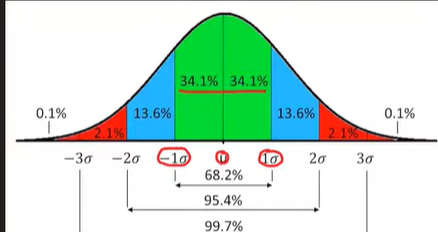

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\Dell\AppData\Local\Temp\ipykernel_13140\138745197.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


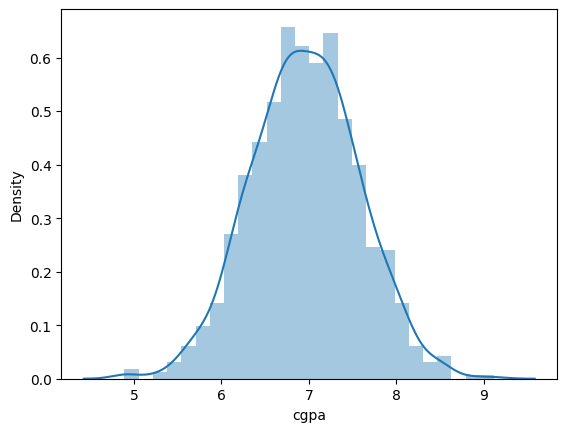

C:\Users\Dell\AppData\Local\Temp\ipykernel_13140\138745197.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


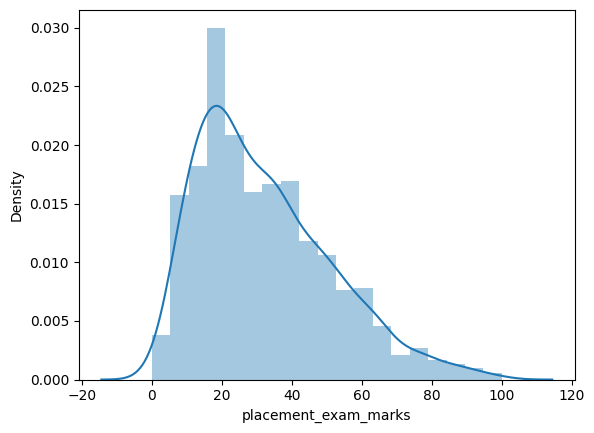

In [11]:
# check if normally distributed or not
import seaborn as sns
import matplotlib.pyplot as plt
sns.distplot(df['cgpa'])
plt.show()
sns.distplot(df['placement_exam_marks'])
plt.show()

In [12]:
# cgpa is normally distributed and exam marks is not
# we wil apply z score on cgpa only

In [21]:
mean=df['cgpa'].mean()

In [22]:
std=df['cgpa'].std()

In [23]:
print(df['cgpa'].min())
print(df['cgpa'].max())


4.89
9.12


In [34]:
df1.shape

(1000, 1)

In [24]:
# values should lie in [mean-3std,mean+3std]
print('values bw',(mean-3*std),(mean+3*std))

values bw 5.113546374602832 8.808933625397168


In [26]:
df1=pd.read_csv('placement.csv',usecols=['cgpa'])

In [ ]:
df1.sample(5)

# Trimming:

In [37]:
new_df1=df1[(df1['cgpa']>5.113546374602832) & (df1['cgpa']<8.808933625397168)]

In [38]:
# this contains data when outliers are removed
new_df1.shape

(995, 1)

In [39]:
# 5 rows removed

In [42]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [46]:
df1_new=scaler.fit_transform(df1)

In [48]:
df1_new

array([[ 3.71611066e-01],
       [ 8.10214789e-01],
       [ 9.40171448e-01],
       [-8.79221775e-01],
       [ 4.36589395e-01],
       [ 5.50301472e-01],
       [-4.40618052e-01],
       [ 2.57898989e-01],
       [-8.30488028e-01],
       [ 1.28130768e+00],
       [-2.29438481e-01],
       [-9.44200105e-01],
       [-6.19308458e-01],
       [-2.08132087e+00],
       [ 1.54122100e+00],
       [ 2.25409825e-01],
       [-7.00531369e-01],
       [ 9.72660613e-01],
       [-5.07480753e-02],
       [ 1.08637269e+00],
       [-4.40618052e-01],
       [ 7.61481042e-01],
       [-3.26905975e-01],
       [-1.48027132e+00],
       [-8.46732611e-01],
       [-1.10664593e+00],
       [ 7.93970207e-01],
       [-7.00531369e-01],
       [ 4.36589395e-01],
       [-7.33020534e-01],
       [ 8.10214789e-01],
       [ 1.13510644e+00],
       [-1.70769548e+00],
       [-1.18786884e+00],
       [ 1.93109097e+00],
       [ 8.42703954e-01],
       [-1.80704734e-01],
       [ 2.51589594e+00],
       [-6.1

In [49]:
df1_new=pd.DataFrame(df1_new,columns=['cgpa'])

In [50]:
df1_new

,cgpa
0,0.371611
1,0.810215
2,0.940171
3,-0.879222
4,0.436589
...,...
995,3.100701
996,3.506815
997,-3.364643
998,2.694586


In [51]:
df1_new=df1_new[(df1_new['cgpa']>-3) & (df1_new['cgpa']<3)]

In [52]:
df1_new.shape

(995, 1)

In [53]:
# 5 outliers removed

# Capping

In [55]:
upper_limit=mean+3*std
lower_limit=mean-3*std

In [57]:
df1_cap=np.where(df1['cgpa']>upper_limit, upper_limit,
                np.where(df1['cgpa']<lower_limit,lower_limit,df['cgpa']))

In [67]:
df1_cap=pd.DataFrame(df1_cap,columns=['cgpa'])

In [68]:
df1_cap.describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934


In [69]:
# min, max values have changed